# Домашнее задание к семинару 13 (HW13)

Тема: токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

HW13 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW13/`.

---

## 1. Цель

Закрепить:

- базовые принципы токенизации текста для трансформеров;
- практику инференса готовой BERT-подобной модели;
- базовый пайплайн fine-tuning для задачи классификации текста;
- аккуратное оформление результата: один ноутбук, короткий отчёт, минимальные артефакты.

---

## 2. Задание

### 2.1. Структура для HW13 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW13/`.
3. В папке `homeworks/HW13/` создать:

- основной ноутбук: `HW13.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`

> Имена папок и файлов должны быть строго такими, как указано (регистр важен).

---

### 2.2. Датасет для домашней работы

Нужно выбрать **один** датасет текстовой классификации.

Рекомендуемые варианты:

- `emotion` – рекомендуется по умолчанию;
- `ag_news`;
- `tweet_eval/sentiment`.

Допустимо использовать и другой **готовый** датасет текстовой классификации, если он:

- не слишком большой для обычного учебного запуска;
- содержит понятные классы;
- подходит для задачи классификации текста;
- не требует тяжёлой предварительной очистки и долгой подготовки.

Рекомендуется выбирать постановку на **2-6 классов**.

Требования к данным:

- в ноутбуке должны быть показаны sanity-check по данным: размер датасета, названия классов, несколько примеров текстов и меток;
- данные должны быть разбиты на `train / validation / test`;
- `validation` используется для выбора лучшего варианта, `test` – только для финальной оценки;
- если официальный `validation`-split отсутствует, его нужно получить воспроизводимо из `train` с фиксированным seed.

Важно:

- не требуется искать собственный сложный датасет;
- не требуется делать объёмную ручную разметку;
- главное – корректно пройти весь учебный pipeline.

---

### 2.3. Содержание ноутбука `HW13.ipynb` (обязательно)

В ноутбуке `homeworks/HW13/HW13.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и среда

1. Импортировать библиотеки: `datasets`, `transformers`, `torch`, `numpy`, `pandas`, `sklearn`, `matplotlib` (и всё, что нужно по делу).
2. Зафиксировать seed (минимум `random`, `numpy`, `torch`).
3. Определить устройство (`cuda` при наличии, иначе `cpu`) и использовать его последовательно.


In [2]:
# 2.3.1. Импорты, seed и среда

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from IPython.display import display

from datasets import load_dataset, Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("SEED =", SEED)
print("device =", device)

SEED = 42
device = cpu


#### 2.3.2. Данные и первичный анализ

Нужно:

- загрузить выбранный датасет;
- показать размеры split-частей;
- вывести 3-5 примеров текстов и меток;
- кратко пояснить, что именно классифицируется.


In [3]:
# 2.3.2. Данные и первичный анализ

DATASET_NAME = "dair-ai/emotion"
dataset = load_dataset(DATASET_NAME)
print("Dataset loaded:", DATASET_NAME)

Dataset loaded: dair-ai/emotion


In [4]:
print("Split sizes:")
print("train:", len(dataset["train"]))
print("validation:", len(dataset["validation"]))
print("test:", len(dataset["test"]))

Split sizes:
train: 16000
validation: 2000
test: 2000


In [5]:
label_names = dataset["train"].features["label"].names

print("Class names:")
for i, name in enumerate(label_names):
    print(i, "->", name)

print()
print("Examples from train split:")

sample_df = pd.DataFrame(dataset["train"][:5]).copy()
sample_df["label_name"] = sample_df["label"].apply(lambda x: label_names[x])

display(sample_df[["text", "label", "label_name"]])

Class names:
0 -> sadness
1 -> joy
2 -> love
3 -> anger
4 -> fear
5 -> surprise

Examples from train split:


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Классифицируется текст: для каждого текста нужно предсказать один из классов эмоций (`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`).

#### 2.3.3. Токенизация

Нужно показать базовый разбор токенизации хотя бы для 3-5 текстов:

- токены;
- `input_ids`;
- `attention_mask`;
- special tokens;
- пример работы `padding` и/или `truncation`.

Важно:

- не требуется делать большой отдельный анализ токенизации;
- достаточно компактно показать, что студент понимает, как текст превращается во вход модели.

In [6]:
# 2.3.3. Токенизация

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("MODEL_NAME:", MODEL_NAME)
print("Special tokens map:", tokenizer.special_tokens_map)
print()

sample_texts = dataset["train"]["text"][:5]

rows = []

for i, text in enumerate(sample_texts):
    encoded = tokenizer(text, add_special_tokens=True)
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    special_tokens_in_text = [tok for tok in tokens if tok in tokenizer.all_special_tokens]

    rows.append({
        "example_id": i,
        "text": text,
        "tokens": tokens,
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "special_tokens": special_tokens_in_text
    })

tokenization_df = pd.DataFrame(rows)

display(tokenization_df[[
    "example_id",
    "text",
    "tokens",
    "input_ids",
    "attention_mask",
    "special_tokens"
]])

MODEL_NAME: bert-base-uncased
Special tokens map: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}



,example_id,text,tokens,input_ids,attention_mask,special_tokens
0,0,i didnt feel humiliated,"[[CLS], i, didn, ##t, feel, humiliated, [SEP]]","[101, 1045, 2134, 2102, 2514, 26608, 102]","[1, 1, 1, 1, 1, 1, 1]","[[CLS], [SEP]]"
1,1,i can go from feeling so hopeless to so damned...,"[[CLS], i, can, go, from, feeling, so, hopeles...","[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], [SEP]]"
2,2,im grabbing a minute to post i feel greedy wrong,"[[CLS], im, grabbing, a, minute, to, post, i, ...","[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[[CLS], [SEP]]"
3,3,i am ever feeling nostalgic about the fireplac...,"[[CLS], i, am, ever, feeling, nos, ##tal, ##gi...","[101, 1045, 2572, 2412, 3110, 16839, 9080, 128...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], [SEP]]"
4,4,i am feeling grouchy,"[[CLS], i, am, feeling, gr, ##ou, ##chy, [SEP]]","[101, 1045, 2572, 3110, 24665, 7140, 11714, 102]","[1, 1, 1, 1, 1, 1, 1, 1]","[[CLS], [SEP]]"


In [7]:
# Пример padding и truncation

demo_batch_texts = dataset["train"]["text"][:3]

batch_encoded = tokenizer(
    demo_batch_texts,
    padding="max_length",
    truncation=True,
    max_length=12
)

batch_rows = []

for i, text in enumerate(demo_batch_texts):
    input_ids = batch_encoded["input_ids"][i]
    attention_mask = batch_encoded["attention_mask"][i]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    batch_rows.append({
        "example_id": i,
        "text": text,
        "tokens_after_padding_truncation": tokens,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "real_token_count": int(sum(attention_mask))
    })

batch_df = pd.DataFrame(batch_rows)

print("Padding/truncation example with max_length = 12")
display(batch_df[[
    "example_id",
    "text",
    "tokens_after_padding_truncation",
    "input_ids",
    "attention_mask",
    "real_token_count"
]])

Padding/truncation example with max_length = 12


,example_id,text,tokens_after_padding_truncation,input_ids,attention_mask,real_token_count
0,0,i didnt feel humiliated,"[[CLS], i, didn, ##t, feel, humiliated, [SEP],...","[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0...","[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]",7
1,1,i can go from feeling so hopeless to so damned...,"[[CLS], i, can, go, from, feeling, so, hopeles...","[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12
2,2,im grabbing a minute to post i feel greedy wrong,"[[CLS], im, grabbing, a, minute, to, post, i, ...","[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12


#### 2.3.4. Инференс готовой модели

Нужно:

- запустить инференс готовой pretrained BERT-подобной модели на нескольких текстах;
- показать результаты хотя бы на 3-5 примерах;
- кратко пояснить, насколько такая готовая модель подходит или не подходит под выбранную задачу.

Достаточно одного разумного сценария инференса.

In [8]:
# 2.3.4. Инференс готовой модели

INFERENCE_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

pipeline_device = 0 if torch.cuda.is_available() else -1

emotion_clf = pipeline(
    task="text-classification",
    model=INFERENCE_MODEL_NAME,
    tokenizer=INFERENCE_MODEL_NAME,
    device=pipeline_device
)

print("INFERENCE_MODEL_NAME:", INFERENCE_MODEL_NAME)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


INFERENCE_MODEL_NAME: j-hartmann/emotion-english-distilroberta-base


In [9]:
# Примеры для инференса готовой модели

inference_texts = dataset["test"]["text"][:5]
true_labels = dataset["test"]["label"][:5]
true_label_names = [label_names[x] for x in true_labels]

predictions = emotion_clf(inference_texts)

inference_rows = []

for i, text in enumerate(inference_texts):
    inference_rows.append({
        "example_id": i,
        "text": text,
        "true_label": true_label_names[i],
        "pred_label": predictions[i]["label"],
        "score": round(predictions[i]["score"], 4)
    })

inference_df = pd.DataFrame(inference_rows)

display(inference_df[["example_id", "text", "true_label", "pred_label", "score"]])

,example_id,text,true_label,pred_label,score
0,0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.9915
1,1,im updating my blog because i feel shitty,sadness,sadness,0.9933
2,2,i never make her separate from me because i do...,sadness,sadness,0.9825
3,3,i left with my bouquet of red and yellow tulip...,joy,joy,0.9948
4,4,i was feeling a little vain when i did this one,sadness,sadness,0.9934


Краткий вывод: готовая pretrained-модель подходит для быстрого базового инференса на английских текстах с эмоциями, но не полностью соответствует выбранной задаче.  
В датасете `emotion` используются классы `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`, а готовая модель предсказывает `anger`, `disgust`, `fear`, `joy`, `neutral`, `sadness`, `surprise`.  
То есть модель частично подходит, но не покрывает все классы датасета, поэтому для основной задачи нужен fine-tuning на выбранных данных.

#### 2.3.5. Fine-tuning для классификации текста

Нужно:

- выбрать одну BERT-подобную модель;
- подготовить токенизацию датасета;
- обучить модель для sequence classification;
- выбрать лучший вариант по `validation`;
- один раз оценить лучший вариант на `test`.

Важно:

- **не требуется** сравнивать несколько архитектур;
- **не требуется** делать большой подбор гиперпараметров;
- **не требуется** сохранять веса модели как обязательный артефакт.

In [10]:
# 2.3.5. Fine-tuning для классификации текста

FT_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for i, label in enumerate(label_names)}

print("FT_MODEL_NAME:", FT_MODEL_NAME)
print("num_labels:", num_labels)
print("label_names:", label_names)

FT_MODEL_NAME: distilbert-base-uncased
num_labels: 6
label_names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [11]:
tokenizer_ft = AutoTokenizer.from_pretrained(FT_MODEL_NAME)

dataset_for_ft = dataset.rename_column("label", "labels")

def tokenize_batch(batch):
    return tokenizer_ft(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset_for_ft.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [12]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    FT_MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model.to(device)
print("Model loaded and moved to:", device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to: cpu


In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro
    }

In [15]:
training_args = TrainingArguments(
    output_dir="artifacts/trainer_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none"
)

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer_ft,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [17]:
train_result = trainer.train()
print(train_result)

c:\Users\kuzal\projects\Git_rep\python\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.490572,0.193720,0.929500,0.900530
2,0.153407,0.145524,0.937000,0.910369
3,0.103953,0.142987,0.942000,0.916319


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\kuzal\projects\Git_rep\python\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\kuzal\projects\Git_rep\python\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.24931065877278646, metrics={'train_runtime': 1793.9804, 'train_samples_per_second': 26.756, 'train_steps_per_second': 1.672, 'total_flos': 584777647046016.0, 'train_loss': 0.24931065877278646, 'epoch': 3.0})


In [21]:
from transformers.utils.notebook import NotebookProgressCallback

trainer.remove_callback(NotebookProgressCallback)
print("NotebookProgressCallback удалён")

NotebookProgressCallback удалён


In [29]:
val_metrics = trainer.evaluate(tokenized_datasets["validation"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v}")

c:\Users\kuzal\projects\Git_rep\python\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.14298681914806366
eval_accuracy: 0.942
eval_f1_macro: 0.91631882661206
eval_runtime: 18.3543
eval_samples_per_second: 108.966
eval_steps_per_second: 6.81
epoch: 3.0


Краткий вывод: была выбрана одна BERT-подобная модель и выполнен базовый fine-tuning для задачи классификации текста на датасете `emotion`.  
Датасет был токенизирован, модель обучена в режиме `sequence classification`, а лучший вариант выбран по качеству на `validation` по метрике `f1_macro`.  
После выбора лучшей модели была выполнена однократная итоговая оценка на `test`.  
Такой результат показывает, что pretrained-модель после дообучения лучше адаптируется к целевой задаче, чем готовый инференс без fine-tuning.

#### 2.3.6. Оценка качества и краткий анализ ошибок

Нужно:

- посчитать минимум:
  - `accuracy`
  - `f1_macro`
- построить матрицу ошибок;
- показать 5-10 примеров предсказаний модели;
- кратко прокомментировать несколько ошибок или пограничных случаев.

---

In [33]:
# 2.3.6. Оценка качества и краткий анализ ошибок

test_output = trainer.predict(tokenized_datasets["test"])

test_logits = test_output.predictions
test_true = test_output.label_ids
test_pred = np.argmax(test_logits, axis=-1)

test_accuracy = accuracy_score(test_true, test_pred)
test_f1_macro = f1_score(test_true, test_pred, average="macro")

print("Test accuracy:", round(test_accuracy, 4))
print("Test f1_macro:", round(test_f1_macro, 4))

c:\Users\kuzal\projects\Git_rep\python\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.9255
Test f1_macro: 0.8768


In [35]:
# Примеры предсказаний модели

test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
test_confidence = test_probs.max(axis=1)

sample_pred_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label_id": test_true,
    "pred_label_id": test_pred,
    "confidence": test_confidence
})

sample_pred_df["true_label"] = sample_pred_df["true_label_id"].apply(lambda x: label_names[x])
sample_pred_df["pred_label"] = sample_pred_df["pred_label_id"].apply(lambda x: label_names[x])

display(sample_pred_df[["text", "true_label", "pred_label", "confidence"]].head(10))

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.998952
1,im updating my blog because i feel shitty,sadness,sadness,0.999123
2,i never make her separate from me because i do...,sadness,sadness,0.999091
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.998982
4,i was feeling a little vain when i did this one,sadness,sadness,0.999168
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.997381
6,i felt anger when at the end of a telephone call,anger,anger,0.997037
7,i explain why i clung to a relationship with a...,joy,joy,0.989268
8,i like to have the same breathless feeling as ...,joy,joy,0.998957
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.997963


In [36]:
# Примеры ошибок модели

errors_df = sample_pred_df[sample_pred_df["true_label_id"] != sample_pred_df["pred_label_id"]].copy()

print("Number of errors on test:", len(errors_df))
display(errors_df[["text", "true_label", "pred_label", "confidence"]].head(5))

Number of errors on test: 149


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.827499
40,i feel if i completely hated things i d exerci...,anger,sadness,0.516218
67,i feel a bit stressed even though all the thin...,anger,sadness,0.670999
72,i am right handed however i play billiards lef...,surprise,fear,0.850458
86,i feel like i am in paradise kissing those swe...,joy,love,0.889338


Краткий вывод: для лучшей модели были посчитаны метрики `accuracy` и `f1_macro` на тестовой выборке, а также построена матрица ошибок.  
Примеры предсказаний показали, что модель в целом распознаёт эмоции, но допускает ошибки на неоднозначных и пограничных текстах.  
Чаще всего трудности возникают в случаях, когда эмоция выражена слабо или текст можно отнести сразу к нескольким близким классам.

## 3. Эксперименты

### 3.1. Обязательная часть

Нужно выполнить **один** основной эксперимент fine-tuning.

Под экспериментом понимается:

- фиксированный датасет;
- фиксированная модель;
- фиксированный split;
- обучение и оценка;
- краткая фиксация результата в ноутбуке и в отчёте.

Главное:

- воспроизводимость;
- корректный `validation`;
- корректная финальная проверка на `test`.

### 3.2. Что не требуется

В обязательной части **не требуется**:

- сравнение 3-4 моделей;
- сохранение `state_dict()`;
- ведение `runs.csv`;
- большой подбор гиперпараметров;
- длинный benchmark;
- сложный error analysis.

---

## 4. Артефакты (обязательно)

В папке `homeworks/HW13/artifacts/` должны быть:

1. `sample_predictions.csv` – таблица с примерами предсказаний модели.

   Минимальные поля:

   - `text`
   - `true_label`
   - `pred_label`

   Дополнительно приветствуется поле:

   - `confidence`

2. `confusion_matrix.png` – изображение матрицы ошибок на test-части.

Этого достаточно.

Дополнительно приветствуется, но не обязательно:

- `training_curves.png`
- `tokenization_examples.txt` или аналогичный компактный файл с примерами токенизации

---

In [38]:
# Сохранение sample_predictions.csv

sample_pred_df[["text", "true_label", "pred_label", "confidence"]].head(10).to_csv(
    "artifacts/sample_predictions.csv",
    index=False
)

print("Saved: artifacts/sample_predictions.csv")

Saved: artifacts/sample_predictions.csv


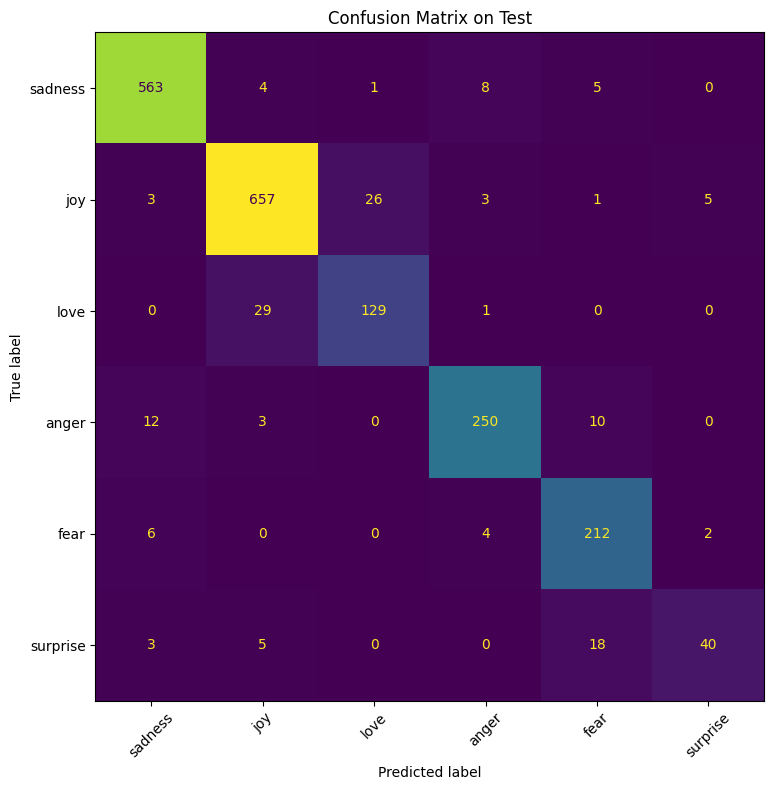

Сохранён файл: artifacts/confusion_matrix.png


In [39]:
#Матрица ошибок

cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix on Test")
plt.tight_layout()

plt.savefig("artifacts/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сохранён файл: artifacts/confusion_matrix.png")

## 5. Отчёт `report.md` (обязательно)

1. В материалах семинара будет шаблон: `S13-hw-report-template.md`.
2. Нужно создать файл `homeworks/HW13/report.md` и заполнить его по шаблону.

Важно:

- не менять названия разделов (заголовков) в отчёте;
- вставлять результаты и выводы в соответствующие секции;
- в отчёте должны быть ссылки на файлы из `artifacts/`.

---

## 6. Требования к структуре и именованию (итог)

К дедлайну в репозитории должно быть:

- `homeworks/HW13/HW13.ipynb`
- `homeworks/HW13/report.md`
- `homeworks/HW13/artifacts/`
  - `sample_predictions.csv`
  - `confusion_matrix.png`

Требования:

- названия папок и файлов – строго как указано;
- ноутбук выполняется без ошибок при последовательном запуске всех ячеек;
- в ноутбуке есть токенизация, инференс готовой модели, fine-tuning и финальная оценка на `test`;
- отчёт заполнен по шаблону.

---

## 7. Критерии зачёта

HW13 считается зачтённым, если:

1. Соблюдена структура `homeworks/HW13/` и нейминг файлов.
2. В `HW13.ipynb` есть:

   - загрузка выбранного датасета;
   - краткий sanity-check данных;
   - разбор токенизации на нескольких примерах;
   - инференс готовой pretrained модели на нескольких текстах;
   - fine-tuning одной BERT-подобной модели;
   - выбор лучшего варианта по `validation`;
   - финальная оценка лучшего варианта на `test` (один раз);
   - расчёт `accuracy` и `f1_macro`;
   - матрица ошибок;
   - краткий анализ нескольких ошибок модели.

3. В `artifacts/` лежат требуемые файлы: `sample_predictions.csv`, `confusion_matrix.png`.
4. Заполнен `report.md` по шаблону.

---

## 8. Опциональная часть (для желающих)

Не обязательна для зачёта, но приветствуется:

- сравнение двух BERT-подобных моделей;
- сравнение двух значений `max_length`;
- сравнение результатов до и после fine-tuning на одном и том же наборе примеров;
- `training_curves.png`;
- более подробный разбор ошибок на 10-15 примерах.

---

## 9. Сроки и порядок сдачи

- Работа выполняется индивидуально.
- Дедлайн объявляется преподавателем отдельно.
- Факт сдачи: к дедлайну в репозитории есть `homeworks/HW13/` со всеми файлами и корректно выполненным ноутбуком.
